In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
# creating gates
from quantum_logical.gate_extender import Gate_extender, Convert_levels
dim = 2
N = 5
# creating the set of cnots (this will operate between the g and e levels)
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)
 
cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

# the x_gate needs to be made in a qutrit gate and will involve conversion 
x_gate = qt.Qobj([[0, 1],[1, 0]])
# z_gate = 1/np.sqrt(3) * qt.Qobj([[1, 0, 0],[0, 1, 0], [0, 0, -1]])

# hadamard gate
# hada = 1/np.sqrt(3) * qt.Qobj([[1, 1, 1],[1, -1/2 + np.sqrt(3)*1j/2, -1/2 - np.sqrt(3)*1j/2], [1, -1/2 - np.sqrt(3)*1j/2, -1/2 + np.sqrt(3)*1j/2]])
hada = qt.Qobj([[1/np.sqrt(2), 0, 1/np.sqrt(2)], [0, 1, 0], [1/np.sqrt(2), 0, -1/np.sqrt(2)]])


# new set of qutrit gates 
# extension of the gates into the qutrit space 
# need to make the gate extender take the individual qudit counts at every instance 
gate_extention = Gate_extender(num_qubits=1)
x_gate = gate_extention.qubit_to_qudit(gate=x_gate, from_dim=dim, to_dim=3)
gate_extention = Gate_extender(num_qubits=N)
cnot1 = gate_extention.qubit_to_qudit(gate=cnot1, from_dim=dim, to_dim=3)
cnot2 = gate_extention.qubit_to_qudit(gate=cnot2, from_dim=dim, to_dim=3)
cnot3 = gate_extention.qubit_to_qudit(gate=cnot3, from_dim=dim, to_dim=3)
cnot4 = gate_extention.qubit_to_qudit(gate=cnot4, from_dim=dim, to_dim=3)
cnot5 = gate_extention.qubit_to_qudit(gate=cnot5, from_dim=dim, to_dim=3)
cnot6 = gate_extention.qubit_to_qudit(gate=cnot6, from_dim=dim, to_dim=3)

# conversion of some of the gates into the qutrit space 
new_dim = 3
converter = Convert_levels(num_qubits=1)
x_gate = converter.level_conversion(levels=[0,2], dim=new_dim, gate=x_gate)
converter = Convert_levels(num_qubits=N)
cnot1= converter.level_conversion(levels=[1,2], dim=new_dim, gate=cnot1)
cnot2= converter.level_conversion(levels=[1,2], dim=new_dim, gate=cnot2)

x_layer = tensor(tensor([x_gate] * 3), tensor([qt.qeye(new_dim)] * 2))
hada_layer = tensor(tensor([hada] * 3), tensor([qt.qeye(new_dim)] * 2))

C:\Users\girgi\AppData\Local\Temp\ipykernel_18696\4234291739.py:6: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
C:\Users\girgi\AppData\Local\Temp\ipykernel_18696\4234291739.py:7: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
C:\Users\girgi\AppData\Local\Temp\ipykernel_18696\4234291739.py:9: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot

In [3]:
def neilson_fid(rho, sigma):
    return (((rho.sqrtm()) * sigma * (rho.sqrtm())).sqrtm()).tr()

In [4]:
# building the correction z_gate 
correction_x = qt.Qobj([[0, 1],[1, 0]])
gate_extention = Gate_extender(num_qubits=1)
correction_x = gate_extention.qubit_to_qudit(gate=correction_x, from_dim=dim, to_dim=3)
converter = Convert_levels(num_qubits=1)
correction_x = converter.level_conversion(levels=[1,2], dim=new_dim, gate=correction_x)

In [5]:
correction_z = (hada * correction_x * hada.dag())
correction_z

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]]

In [6]:
# generating parameters and creating initial state
T1 = 5
T2 = 5

dim = new_dim
trotter_dt = .005

# initializing Trotterization
trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N, qudit="qutrit")

In [7]:
# creating initial state
# state controls 
alpha = 0
beta = 1

# state
psi0 = tensor((alpha * basis(dim, 0) + beta * basis(dim, 2)).unit(), tensor([basis(dim, 0)] * (N-1)))

rho0 = psi0 * psi0.dag()
encoded_rho = rho_encoded = hada_layer * cnot1 * rho0 * cnot1.dag()  * hada_layer.dag()

rho_encoded_traced = qt.ptrace(rho_encoded, [0,1,2]) 

rho_encoded_traced # density matrix print confirmation

Quantum object: dims = [[3, 3, 3], [3, 3, 3]], shape = (27, 27), type = oper, isherm = True
Qobj data =
[[ 0.125  0.     0.125  0.     0.     0.    -0.125  0.    -0.125  0.
   0.     0.     0.     0.     0.     0.     0.     0.    -0.125  0.
  -0.125  0.     0.     0.     0.125  0.     0.125]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.125  0.     0.125  0.     0.     0.    -0.125  0.    -0.125  0.
   0.     0.     0.     0.     0.     0.     0.     0.    -0.125  0.
  -0.125  0.     0.     0.     0.125  0.     0.125]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0

In [8]:
basis0 = qt.Qobj([[1],[0],[0]])
basis1 = qt.Qobj([[0],[1],[0]])
basis2 = qt.Qobj([[0],[0],[1]])
vector0 = hada * basis0
vector1 = hada * basis1
vector2 = hada * basis2
vectors = [vector0, vector1, vector2]
vectors = [tensor(i,j,k) for i in vectors for j in vectors for k in vectors]

In [9]:
vals = []
for vec in vectors:
    val = (vec.dag() * qt.ptrace(rho_encoded, [0,1,2]) * vec)[0][0][0]
    vals.append(val)
vals

[0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 0j,
 (0.999999999999999+0j),
 0j,
 0j]

trace throught his with the correction in order to make sure that is works as expected

the projectors work this is fine, and the vector values in the states add up as expected

In [10]:
def sim_func(rho_encoded, T1, T2):

    # initializing Trotterization
    trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N, qudit="qutrit")
    
    # stored information
    states = []
    no_error_states = []

    # gate setups 
    # gates = [[x_layer], [cnot3], [cnot4], [cnot5], [cnot6], [x_layer]]
    # cnot_time = .5
    # gate_times = [.025, cnot_time, cnot_time, cnot_time, cnot_time, .025]
    gates = [[x_layer], [cnot3, cnot5], [cnot4, cnot6], [x_layer]]
    cnot_time = .5
    gate_times = [.025, cnot_time, cnot_time, .025]

    # stabilizer extraction
    rho_encoded = hada_layer * rho_encoded * hada_layer.dag()
    rho_encoded1 = hada_layer * encoded_rho * hada_layer.dag() # point of reference when calculating fidelity 

    for i in range(len(gates)):
        rho_evo = trotter.apply(rho=rho_encoded, duration=gate_times[i], unitary=gates[i], errors=True)
        rho_evo_no_error = trotter.apply(rho=rho_encoded1, duration=gate_times[i], unitary=gates[i], errors=False)
        states.extend(rho_evo)
        no_error_states.extend(rho_evo_no_error)
        rho_encoded = rho_evo[-1]
        rho_encoded1 = rho_evo_no_error[-1]
        
    states.append(hada_layer * rho_encoded * hada_layer.dag())
    no_error_states.append(hada_layer * rho_encoded1 * hada_layer.dag())

    # measurement
    phys_list = [vector0, vector1]
    vals = []
    for vec in phys_list:
        val = (vec.dag() * qt.ptrace(states[-1], [0]) * vec)[0][0][0]
        vals.append(val)
    phys = np.abs(sum(vals))

    # projection operators  
    proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) for i in range(2) for j in range(2)]


    # look into how to get the projection results before moving forward be satisified with it 
    projection_results = [(states[-1] * proj[i]).tr() for i in range(len(proj))]

    # correction_operators
    r00 = qt.tensor([qt.qeye(dim)] * 5)
    r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), correction_z, qt.tensor([qt.qeye(dim)] * 2))
    r10 = qt.tensor(correction_z, qt.tensor([qt.qeye(dim)] * 4))
    r11 = qt.tensor(qt.qeye(dim), correction_z, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
    recovery_ops = [[r00], [r01], [r10], [r11]]

    rec = [[proj[0], r00], [proj[1], r01], [proj[2], r10], [proj[3], r11]]

    import random

    # result = random.choices(rec, projection_results)
    # print(projection_results)
    # print(result)

    logicals = [vectors[24], vectors[20], vectors[8], vectors[-1]]
    vals = []
    for vec in logicals:
        val = (vec.dag() * qt.ptrace(states[-1], [0,1,2]) * vec)[0][0][0]
        vals.append(val)
    uncorrectable_error = 1 - np.abs(sum(vals))
    correctable_error = np.abs(sum(vals))

    # logicals = [vectors[24]]
    # vals = []
    # for vec in logicals:
    #     val = (vec.dag() * qt.ptrace(states[-1], [0,1,2]) * vec)[0][0][0]
    #     vals.append(val)
    # logical1 = np.abs(sum(vals))

    detectable_error = sum([projection_results[i] for i in [0,2,3]]) # this is my metric for logical error 
    
        # imperfect measurement 
    projected_states = []
    measurement_duration = .005
    # for i in proj:
    #     projected_state = trotter.apply(states[-1], duration=measurement_duration, unitary=[i], errors=False)
    #     projected_states.append(projected_state)
    for i in range(len(proj)):
        projected_state = trotter.apply(states[-1], duration=measurement_duration, unitary=[proj[i]], errors=True)
        projected_states.append(projected_state)
    # no_error_projection = trotter.apply(no_error_states[-1], duration=measurement_duration, unitary=[tensor([qt.qeye(dim)] * N)], errors=False)
    # no_error_states.extend(no_error_projection)


    # recovery 
    corrected_states = []
    recovery_duration = .025
    # for i in range(len(projected_states)):
    #     corrected_state = trotter.apply(projected_states[i][-1], duration=recovery_duration, unitary=recovery_ops[i], errors=True)
    #     corrected_states.append(corrected_state)
    for i in range(len(recovery_ops)):
        corrected_state = trotter.apply(projected_states[i][-1], duration=recovery_duration, unitary=recovery_ops[i], errors=True)
        corrected_states.append(corrected_state)

    for i in range(len(corrected_state)):
        new_state = sum([projection_results[j] * corrected_states[j][i] for j in range(len(projection_results))])
        states.append(new_state)
        no_error_states.append(no_error_states[-1])
    # no_error_states.append([no_error_states[-1]] * len(corrected_state))
    # states.extend(corrected_state)

    # for i in range(len(corrected_state)):
    #     combined_corrected_state = sum([projection_results[j] * corrected_states[j][i] for j in range(len(corrected_states))])
    #     states.append(combined_corrected_state)
    #     no_error_states.append(no_error_states[-1])
    logicals = [vectors[-1]]
    vals = []
    for vec in logicals:
        val = (vec.dag() * qt.ptrace(states[-1], [0,1,2]) * vec)[0][0][0]
        vals.append(val)
    errors_after_correction = 1 - np.abs(sum(vals))

    # total_time = recovery_duration + measurement_duration + sum(gate_times)

    return errors_after_correction, states, no_error_states, detectable_error, uncorrectable_error, correctable_error

In [11]:
iterations = 300
states = []
no_error_states = []
fid = []
errors_after_corrections = []
detectable_errors = []
uncorrectable_errors = []
correctable_errors = []
phs = []
t1_list = np.linspace(.1, 120, iterations)
for i in tqdm(range(iterations)):
    errors_after_correction, state, no_error, detectable_error, uncorrectable_error, correctable_error = sim_func(rho_encoded=rho_encoded, T1=t1_list[i], T2=t1_list[i])
    states.extend(state)
    no_error_states.extend(no_error)
    # phs.append(errors_after_correction)
    errors_after_corrections.append(errors_after_correction)
    detectable_errors.append(detectable_error)
    uncorrectable_errors.append(uncorrectable_error)
    correctable_errors.append(correctable_error)

  0%|          | 0/300 [00:00<?, ?it/s]

  4%|▍         | 12/300 [00:48<19:08,  3.99s/it]

all of the values work as expected the important thing now is to make plots that make sense and give some information.
do this for both the 5 wave and 3 wave and then do it for the step up gate and see how these compare to each other. 
Then start looking into erasures. Tomorrow should be the deadline that i set for myself to get something to him via slack and get something out there. 
give meaningful plots. Think about reporting both the averaged trials and the individual only trials based on the results that you expect to see 

Make a list of all you want to calculate and why they are being plotted. <br />
1. how many detectable errors are in the system at the end of the syndrome extraction as a function of t1 <br />
2. how much of the system is in a correctable state at the end of the syndrome as a function of t1 <br />
3. how much of the system is corrected after the correction protocol as a function of how many errors there were to begin with<br />
4. some graph or correctable vs detectable errors in the system<br />
(do this for .05 t1 to 2 and then again for .05 to 80 with the appropriate gaps)

In [ ]:
import csv


# Writing the arrays to a CSV file
with open('multiple_arrays1_parallel.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(errors_after_corrections)  # Save array1 as a row
    writer.writerow(detectable_errors)  # Save array2 as a row
    writer.writerow(uncorrectable_errors)  # Save array1 as a row
    writer.writerow(correctable_errors)  # Save array2 as a row

print("Multiple arrays have been saved to multiple_arrays.csv")


Multiple arrays have been saved to multiple_arrays.csv


Text(0.5, 1.0, 'Detectable errors vs Decoherence')

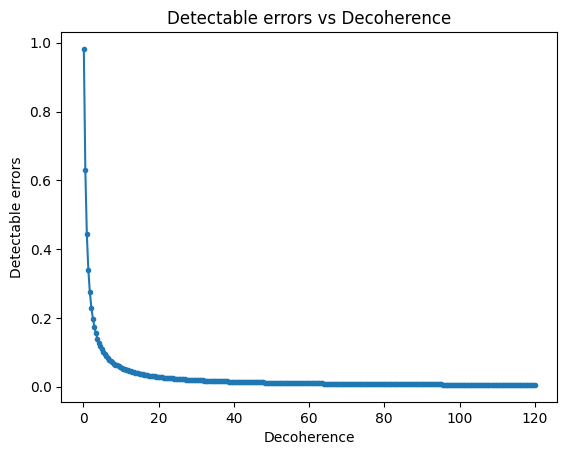

In [ ]:
fig, ax = plt.subplots()
ax.plot(t1_list, detectable_errors, marker=".")
ax.set_xlabel("Decoherence")
ax.set_ylabel("Detectable errors")
ax.set_title("Detectable errors vs Decoherence")

Text(0.5, 1.0, 'Uncorrectable errors vs decoherence')

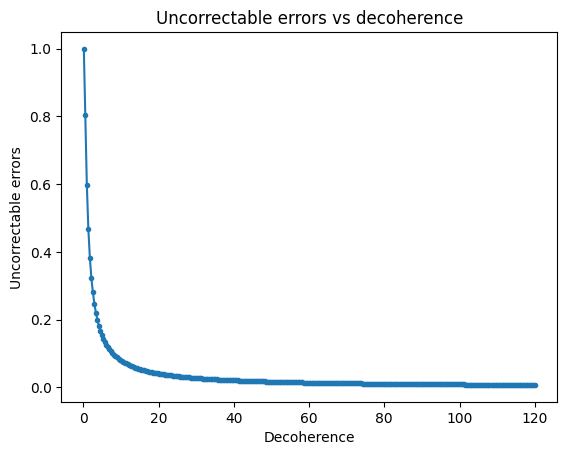

In [ ]:
fig, ax = plt.subplots()
ax.plot(t1_list, uncorrectable_errors, marker=".")
ax.set_xlabel("Decoherence")
ax.set_ylabel("Uncorrectable errors")
ax.set_title("Uncorrectable errors vs decoherence")

Text(0.5, 1.0, 'Errors after correction vs Correctable errors')

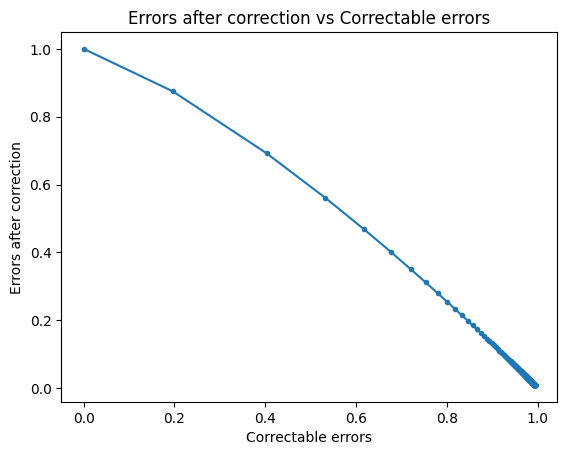

In [ ]:
fig, ax = plt.subplots()
ax.plot(correctable_errors, errors_after_corrections, marker=".")
ax.set_xlabel("Correctable errors")
ax.set_ylabel("Errors after correction")
ax.set_title("Errors after correction vs Correctable errors")

Text(0.5, 1.0, 'Correctable errors vs detected errors')

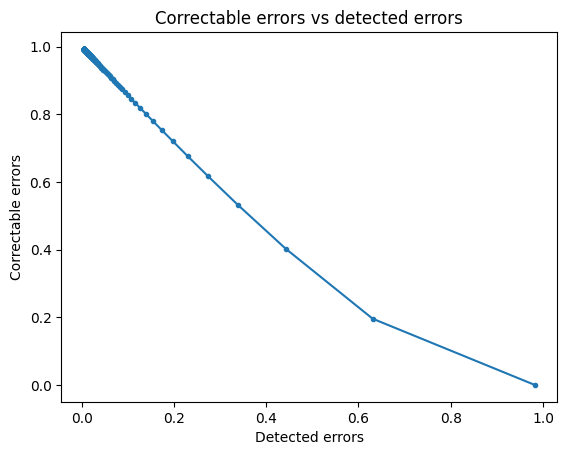

In [ ]:
fig, ax = plt.subplots()
ax.plot(detectable_errors, correctable_errors, marker=".")
ax.set_xlabel("Detected errors")
ax.set_ylabel("Correctable errors")
ax.set_title("Correctable errors vs detected errors")